#Importing libraries and necessary files

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# ============================================================
# Load the saved train_df.csv / test_df.csv
TARGET_COL = "band_gap"
train_df = pd.read_csv("train_df.csv")
test_df = pd.read_csv("test_df.csv")

with open("column_groups.json") as f:
    column_groups = json.load(f)

elemental_cols = column_groups["elemental"]
geometrical_cols = column_groups["geometrical"]
structural_cols = column_groups["structural"]

print(f"Elemental columns   : {len(elemental_cols)}")
print(f"Geometrical columns : {len(geometrical_cols)}")
print(f"Structural columns  : {len(structural_cols)}")
print(f"Train shape: {train_df.shape}  Test shape: {test_df.shape}")

# Sanity check: confirm every listed column actually exists in
# the loaded CSVs -- catches a mismatched/stale JSON immediately
# instead of silently producing wrong feature sets later.
all_listed = elemental_cols + geometrical_cols + structural_cols
missing_in_train = [c for c in all_listed if c not in train_df.columns]
missing_in_test = [c for c in all_listed if c not in test_df.columns]
if missing_in_train or missing_in_test:
    raise ValueError(
        f"column_groups.json does not match the loaded CSVs. "
        f"Missing in train_df: {missing_in_train}. "
        f"Missing in test_df: {missing_in_test}. "
        f"Re-run Script 1 to regenerate matching files."
    )

# ============================================================
#   Progressive feature-set column lists
#   1 = Elemental only
#   2 = Elemental + Geometrical
#   3 = Elemental + Geometrical + Structural
cols_set1 = elemental_cols
cols_set2 = elemental_cols + geometrical_cols
cols_set3 = elemental_cols + geometrical_cols + structural_cols

# ============================================================
# Build X_train1/X_test1/y_train1/y_test1, and so on --
X_train1 = train_df[cols_set1].values
X_test1 = test_df[cols_set1].values
y_train1 = train_df[TARGET_COL].values.reshape(-1, 1)
y_test1 = test_df[TARGET_COL].values.reshape(-1, 1)

X_train2 = train_df[cols_set2].values
X_test2 = test_df[cols_set2].values
y_train2 = train_df[TARGET_COL].values.reshape(-1, 1)
y_test2 = test_df[TARGET_COL].values.reshape(-1, 1)

X_train3 = train_df[cols_set3].values
X_test3 = test_df[cols_set3].values
y_train3 = train_df[TARGET_COL].values.reshape(-1, 1)
y_test3 = test_df[TARGET_COL].values.reshape(-1, 1)

print(f"\nX_train1/X_test1: {X_train1.shape} / {X_test1.shape}")
print(f"X_train2/X_test2: {X_train2.shape} / {X_test2.shape}")
print(f"X_train3/X_test3: {X_train3.shape} / {X_test3.shape}")


Elemental columns   : 137
Geometrical columns : 5
Structural columns  : 8
Train shape: (1992, 154)  Test shape: (352, 154)

X_train1/X_test1: (1992, 137) / (352, 137)
X_train2/X_test2: (1992, 142) / (352, 142)
X_train3/X_test3: (1992, 150) / (352, 150)


#Ensemble Learning

##Random Forest

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
warnings.filterwarnings("ignore")

#10 fold Cross validation
models = {
    "Model 1": (X_train1, y_train1),
    "Model 2": (X_train2, y_train2),
    "Model 3": (X_train3, y_train3)
}

cv_results = {}

for name, (X, y) in models.items():

    rf = RandomForestRegressor(random_state=100)

    mse_scores = cross_val_score(
        estimator=rf,
        X=X,
        y=y,
        cv=10,
        scoring="neg_mean_squared_error"
    )

    rmse_scores = np.sqrt(-mse_scores)

    cv_results[name] = {
        "RMSE_mean": rmse_scores.mean(),
        "RMSE_std": rmse_scores.std(),
        "RMSE_folds": rmse_scores
    }

    print(f"\n{name}")
    print(f"Fold RMSE: {rmse_scores}")
    print(f"Mean RMSE: {rmse_scores.mean():.4f}")
    print(f"Std RMSE : {rmse_scores.std():.4f}")


Model 1
Fold RMSE: [0.86373463 0.8405645  0.84814199 0.84899053 0.77097631 0.8038968
 0.99727137 0.80327945 0.99829352 0.95964551]
Mean RMSE: 0.8735
Std RMSE : 0.0781

Model 2
Fold RMSE: [0.75290979 0.70610792 0.72773644 0.72359541 0.69001649 0.71892066
 0.91406144 0.71444897 0.89701462 0.83026097]
Mean RMSE: 0.7675
Std RMSE : 0.0780

Model 3
Fold RMSE: [0.7402015  0.60782482 0.66111129 0.63462481 0.63625408 0.63243606
 0.89828184 0.66303973 0.85117866 0.76293035]
Mean RMSE: 0.7088
Std RMSE : 0.0955


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
warnings.filterwarnings("ignore")

# Define models
rf1 = RandomForestRegressor(random_state=100)
rf2 = RandomForestRegressor(random_state=100)
rf3 = RandomForestRegressor(random_state=100)

# Fit models
rf1.fit(X_train1, y_train1)
rf2.fit(X_train2, y_train2)
rf3.fit(X_train3, y_train3)


RandomForestRegressor(random_state=100)

In [5]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error
)

# RF1 Metrics
y_pred1 = rf1.predict(X_test1)
y_pred1 = y_pred1.reshape(len(y_pred1), 1)

rf1_r2 = r2_score(y_test1, y_pred1)
rf1_r = np.corrcoef(y_test1.squeeze(), y_pred1.squeeze())[0, 1]
rf1_mae = mean_absolute_error(y_test1, y_pred1)
rf1_medae = median_absolute_error(y_test1, y_pred1)
rf1_mse = mean_squared_error(y_test1, y_pred1)
rf1_rmse = np.sqrt(rf1_mse)

print("RF1 Results")
print("R2:", rf1_r2)
print("R value:", rf1_r)
print("MAE:", rf1_mae)
print("Median Absolute Error:", rf1_medae)
print("MSE:", rf1_mse)
print("RMSE:", rf1_rmse)


# RF2 Metrics
y_pred2 = rf2.predict(X_test2)
y_pred2 = y_pred2.reshape(len(y_pred2), 1)

rf2_r2 = r2_score(y_test2, y_pred2)
rf2_r = np.corrcoef(y_test2.squeeze(), y_pred2.squeeze())[0, 1]
rf2_mae = mean_absolute_error(y_test2, y_pred2)
rf2_medae = median_absolute_error(y_test2, y_pred2)
rf2_mse = mean_squared_error(y_test2, y_pred2)
rf2_rmse = np.sqrt(rf2_mse)

print("\nRF2 Results")
print("R2:", rf2_r2)
print("R value:", rf2_r)
print("MAE:", rf2_mae)
print("Median Absolute Error:", rf2_medae)
print("MSE:", rf2_mse)
print("RMSE:", rf2_rmse)


# =========================
# RF3 Metrics
# =========================
y_pred3 = rf3.predict(X_test3)
y_pred3 = y_pred3.reshape(len(y_pred3), 1)

rf3_r2 = r2_score(y_test3, y_pred3)
rf3_r = np.corrcoef(y_test3.squeeze(), y_pred3.squeeze())[0, 1]
rf3_mae = mean_absolute_error(y_test3, y_pred3)
rf3_medae = median_absolute_error(y_test3, y_pred3)
rf3_mse = mean_squared_error(y_test3, y_pred3)
rf3_rmse = np.sqrt(rf3_mse)

print("\nRF3 Results")
print("R2:", rf3_r2)
print("R value:", rf3_r)
print("MAE:", rf3_mae)
print("Median Absolute Error:", rf3_medae)
print("MSE:", rf3_mse)
print("RMSE:", rf3_rmse)

RF1 Results
R2: 0.7781273655571708
R value: 0.8821441863455066
MAE: 0.4837094527789185
Median Absolute Error: 0.28500479636484355
MSE: 0.5922240567605278
RMSE: 0.7695609506468788

RF2 Results
R2: 0.8504938817171777
R value: 0.9232673743275178
MAE: 0.4050122295644375
Median Absolute Error: 0.23447474557504058
MSE: 0.3990628231476968
RMSE: 0.6317141941952047

RF3 Results
R2: 0.8852675184726341
R value: 0.9423108040669371
MAE: 0.35563770442513737
Median Absolute Error: 0.21397234775822707
MSE: 0.3062447778788475
RMSE: 0.5533938722816214


In [6]:
# =========================
# RF1 Train Metrics
# =========================
y_train_pred1 = rf1.predict(X_train1)
y_train_pred1 = y_train_pred1.reshape(len(y_train_pred1), 1)

rf1_train_r2 = r2_score(y_train1, y_train_pred1)
rf1_train_r = np.corrcoef(y_train1.squeeze(), y_train_pred1.squeeze())[0, 1]
rf1_train_mae = mean_absolute_error(y_train1, y_train_pred1)
rf1_train_medae = median_absolute_error(y_train1, y_train_pred1)
rf1_train_mse = mean_squared_error(y_train1, y_train_pred1)
rf1_train_rmse = np.sqrt(rf1_train_mse)

print("RF1 Train Results")
print("R2:", rf1_train_r2)
print("R value:", rf1_train_r)
print("MAE:", rf1_train_mae)
print("Median Absolute Error:", rf1_train_medae)
print("MSE:", rf1_train_mse)
print("RMSE:", rf1_train_rmse)


# =========================
# RF2 Train Metrics
# =========================
y_train_pred2 = rf2.predict(X_train2)
y_train_pred2 = y_train_pred2.reshape(len(y_train_pred2), 1)

rf2_train_r2 = r2_score(y_train2, y_train_pred2)
rf2_train_r = np.corrcoef(y_train2.squeeze(), y_train_pred2.squeeze())[0, 1]
rf2_train_mae = mean_absolute_error(y_train2, y_train_pred2)
rf2_train_medae = median_absolute_error(y_train2, y_train_pred2)
rf2_train_mse = mean_squared_error(y_train2, y_train_pred2)
rf2_train_rmse = np.sqrt(rf2_train_mse)

print("\nRF2 Train Results")
print("R2:", rf2_train_r2)
print("R value:", rf2_train_r)
print("MAE:", rf2_train_mae)
print("Median Absolute Error:", rf2_train_medae)
print("MSE:", rf2_train_mse)
print("RMSE:", rf2_train_rmse)


# =========================
# RF3 Train Metrics
# =========================
y_train_pred3 = rf3.predict(X_train3)
y_train_pred3 = y_train_pred3.reshape(len(y_train_pred3), 1)

rf3_train_r2 = r2_score(y_train3, y_train_pred3)
rf3_train_r = np.corrcoef(y_train3.squeeze(), y_train_pred3.squeeze())[0, 1]
rf3_train_mae = mean_absolute_error(y_train3, y_train_pred3)
rf3_train_medae = median_absolute_error(y_train3, y_train_pred3)
rf3_train_mse = mean_squared_error(y_train3, y_train_pred3)
rf3_train_rmse = np.sqrt(rf3_train_mse)

print("\nRF3 Train Results")
print("R2:", rf3_train_r2)
print("R value:", rf3_train_r)
print("MAE:", rf3_train_mae)
print("Median Absolute Error:", rf3_train_medae)
print("MSE:", rf3_train_mse)
print("RMSE:", rf3_train_rmse)

RF1 Train Results
R2: 0.8783582318282694
R value: 0.938094942973091
MAE: 0.32894778774834016
Median Absolute Error: 0.17266789956709938
MSE: 0.30290148404199113
RMSE: 0.5503648644690095

RF2 Train Results
R2: 0.9487243704686167
R value: 0.9756079322994202
MAE: 0.21143184044412688
Median Absolute Error: 0.12314565003849809
MSE: 0.12768200030039387
RMSE: 0.35732618194080584

RF3 Train Results
R2: 0.9726754248996854
R value: 0.9878863342493639
MAE: 0.16089020425643222
Median Absolute Error: 0.09119400000000236
MSE: 0.06804122032341207
RMSE: 0.26084712059636017


In [7]:
np.set_printoptions(precision=2, suppress=True)
print(np.concatenate((y_pred1.reshape(len(y_pred1),1), y_test1.reshape(len(y_test1),1)),1))

[[1.15 1.52]
 [0.04 0.  ]
 [0.4  0.  ]
 [0.01 0.  ]
 [1.99 2.61]
 [2.48 2.88]
 [4.1  2.56]
 [3.99 4.37]
 [1.   0.  ]
 [1.06 0.  ]
 [1.24 0.76]
 [0.   0.  ]
 [1.47 0.  ]
 [0.58 2.07]
 [1.06 0.95]
 [0.5  0.  ]
 [0.02 0.  ]
 [3.97 4.14]
 [0.32 0.  ]
 [0.   0.  ]
 [4.71 4.28]
 [0.35 0.6 ]
 [2.48 2.19]
 [0.89 2.68]
 [0.03 0.  ]
 [0.04 0.  ]
 [0.   0.  ]
 [0.27 0.09]
 [0.34 0.  ]
 [0.   0.  ]
 [0.   0.  ]
 [3.25 3.66]
 [3.29 4.59]
 [0.37 0.  ]
 [6.39 6.6 ]
 [0.37 0.  ]
 [0.16 0.47]
 [0.06 0.  ]
 [0.7  0.  ]
 [1.3  1.54]
 [0.09 0.  ]
 [3.32 5.84]
 [0.41 0.65]
 [3.08 1.89]
 [0.18 0.  ]
 [0.   0.  ]
 [0.31 0.6 ]
 [1.29 1.95]
 [2.82 3.14]
 [0.63 0.65]
 [3.08 2.74]
 [0.95 0.98]
 [0.58 0.76]
 [0.07 0.  ]
 [0.03 0.  ]
 [0.78 0.  ]
 [2.36 2.06]
 [4.71 3.01]
 [1.29 0.81]
 [3.34 4.42]
 [0.08 0.39]
 [0.   0.  ]
 [0.42 0.31]
 [0.52 2.4 ]
 [0.   0.  ]
 [0.44 0.  ]
 [0.48 0.28]
 [0.35 0.  ]
 [1.57 2.65]
 [0.63 2.14]
 [0.4  0.  ]
 [1.61 3.03]
 [0.   0.  ]
 [0.5  0.  ]
 [1.92 1.76]
 [5.01 6.07]
 [0.   0.  ]

##RF plots

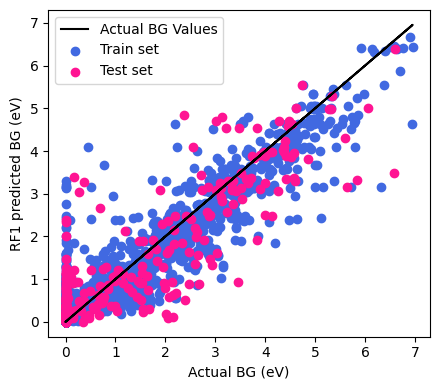

In [8]:
# =========================
# RF1 Plot
# =========================

plt.figure(figsize=(4.5, 4))

# Perfect prediction line
plt.plot(y_train1, y_train1, color='black', label='Actual BG Values')

# Scatter plots
plt.scatter(
    y_train1,
    y_train_pred1,
    color='royalblue',
    #alpha=0.5,
    label=f'Train set'
)

plt.scatter(
    y_test1,
    y_pred1,
    color='deeppink',
    #alpha=0.5,
    label=f'Test set'
    #label=f'Test set: {rf1_rmse:.3f} RMSE'
)

# Labels
plt.xlabel('Actual BG (eV)')
plt.ylabel('RF1 predicted BG (eV)')

# Legend
plt.legend()

# Save figure
plt.savefig('RF1_BG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

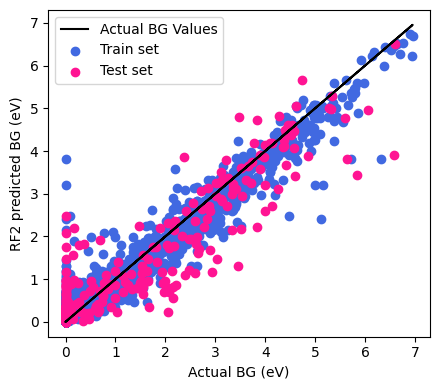

In [9]:
# =========================
# RF2 Plot
# =========================

plt.figure(figsize=(4.5, 4))

# Perfect prediction line
plt.plot(y_train2, y_train2, color='black', label='Actual BG Values')

# Scatter plots
plt.scatter(
    y_train2,
    y_train_pred2,
    color='royalblue',
    #alpha=0.5,
    label=f'Train set'
)

plt.scatter(
    y_test2,
    y_pred2,
    color='deeppink',
    #alpha=0.5,
    label=f'Test set'
)

# Labels
plt.xlabel('Actual BG (eV)')
plt.ylabel('RF2 predicted BG (eV)')

# Legend
plt.legend()

# Save figure
plt.savefig('RF2_BG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

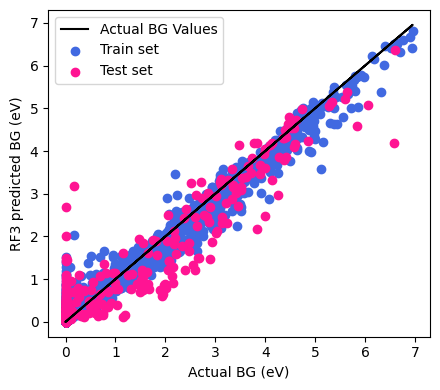

In [10]:
# =========================
# RF3 Plot
# =========================

plt.figure(figsize=(4.5, 4))

# Perfect prediction line
plt.plot(y_train3, y_train3, color='black', label='Actual BG Values')

# Scatter plots
plt.scatter(
    y_train3,
    y_train_pred3,
    color='royalblue',
    #alpha=0.5,
    label=f'Train set'
)

plt.scatter(
    y_test3,
    y_pred3,
    color='deeppink',
    #alpha=0.5,
    label=f'Test set'
)

# Labels
plt.xlabel('Actual BG (eV)')
plt.ylabel('RF3 predicted BG (eV)')

# Legend
plt.legend()

# Save figure
plt.savefig('RF3_BG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

##Gradient Boosting

In [11]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# 10-Fold Cross-Validation for GBR Models

models = {
    "GBR Model 1": (X_train1, y_train1),
    "GBR Model 2": (X_train2, y_train2),
    "GBR Model 3": (X_train3, y_train3)
}

cv_results_gbr = {}

for name, (X, y) in models.items():

    gbr = GradientBoostingRegressor(random_state=100)

    mse_scores = cross_val_score(
        estimator=gbr,
        X=X,
        y=y,
        cv=10,
        scoring="neg_mean_squared_error"
    )

    rmse_scores = np.sqrt(-mse_scores)

    cv_results_gbr[name] = {
        "RMSE_mean": rmse_scores.mean(),
        "RMSE_std": rmse_scores.std(),
        "RMSE_folds": rmse_scores
    }

    print(f"\n{name}")
    print(f"Fold RMSE: {rmse_scores}")
    print(f"Mean RMSE: {rmse_scores.mean():.4f}")
    print(f"Std RMSE : {rmse_scores.std():.4f}")


GBR Model 1
Fold RMSE: [0.87 0.85 0.85 0.8  0.76 0.76 1.02 0.79 0.96 0.92]
Mean RMSE: 0.8571
Std RMSE : 0.0831

GBR Model 2
Fold RMSE: [0.8  0.77 0.78 0.76 0.71 0.68 0.92 0.78 0.93 0.86]
Mean RMSE: 0.8009
Std RMSE : 0.0781

GBR Model 3
Fold RMSE: [0.76 0.64 0.67 0.64 0.68 0.63 0.87 0.71 0.89 0.77]
Mean RMSE: 0.7260
Std RMSE : 0.0880


In [12]:
from sklearn.ensemble import GradientBoostingRegressor
# Define GBR Models

gbr1 = GradientBoostingRegressor(random_state=100)
gbr2 = GradientBoostingRegressor(random_state=100)
gbr3 = GradientBoostingRegressor(random_state=100)

# Fit Models
gbr1.fit(X_train1, y_train1)
gbr2.fit(X_train2, y_train2)
gbr3.fit(X_train3, y_train3)

GradientBoostingRegressor(random_state=100)

In [13]:
# =========================
# GBR1 Metrics
# =========================
gbr_y_pred1 = gbr1.predict(X_test1)

# Replace negative predictions with 0
gbr_y_pred1 = np.clip(gbr_y_pred1, 0, None)

gbr_y_pred1 = gbr_y_pred1.reshape(len(gbr_y_pred1), 1)

gbr1_r2 = r2_score(y_test1, gbr_y_pred1)
gbr1_r = np.corrcoef(y_test1.squeeze(), gbr_y_pred1.squeeze())[0, 1]
gbr1_mae = mean_absolute_error(y_test1, gbr_y_pred1)
gbr1_medae = median_absolute_error(y_test1, gbr_y_pred1)
gbr1_mse = mean_squared_error(y_test1, gbr_y_pred1)
gbr1_rmse = np.sqrt(gbr1_mse)

print("GBR1 Results")
print("R2:", gbr1_r2)
print("R value:", gbr1_r)
print("MAE:", gbr1_mae)
print("Median Absolute Error:", gbr1_medae)
print("MSE:", gbr1_mse)
print("RMSE:", gbr1_rmse)


# =========================
# GBR2 Metrics
# =========================
gbr_y_pred2 = gbr2.predict(X_test2)

# Replace negative predictions with 0
gbr_y_pred2 = np.clip(gbr_y_pred2, 0, None)

gbr_y_pred2 = gbr_y_pred2.reshape(len(gbr_y_pred2), 1)

gbr2_r2 = r2_score(y_test2, gbr_y_pred2)
gbr2_r = np.corrcoef(y_test2.squeeze(), gbr_y_pred2.squeeze())[0, 1]
gbr2_mae = mean_absolute_error(y_test2, gbr_y_pred2)
gbr2_medae = median_absolute_error(y_test2, gbr_y_pred2)
gbr2_mse = mean_squared_error(y_test2, gbr_y_pred2)
gbr2_rmse = np.sqrt(gbr2_mse)

print("\nGBR2 Results")
print("R2:", gbr2_r2)
print("R value:", gbr2_r)
print("MAE:", gbr2_mae)
print("Median Absolute Error:", gbr2_medae)
print("MSE:", gbr2_mse)
print("RMSE:", gbr2_rmse)


# =========================
# GBR3 Metrics
# =========================
gbr_y_pred3 = gbr3.predict(X_test3)

# Replace negative predictions with 0
gbr_y_pred3 = np.clip(gbr_y_pred3, 0, None)

gbr_y_pred3 = gbr_y_pred3.reshape(len(gbr_y_pred3), 1)

gbr3_r2 = r2_score(y_test3, gbr_y_pred3)
gbr3_r = np.corrcoef(y_test3.squeeze(), gbr_y_pred3.squeeze())[0, 1]
gbr3_mae = mean_absolute_error(y_test3, gbr_y_pred3)
gbr3_medae = median_absolute_error(y_test3, gbr_y_pred3)
gbr3_mse = mean_squared_error(y_test3, gbr_y_pred3)
gbr3_rmse = np.sqrt(gbr3_mse)

print("\nGBR3 Results")
print("R2:", gbr3_r2)
print("R value:", gbr3_r)
print("MAE:", gbr3_mae)
print("Median Absolute Error:", gbr3_medae)
print("MSE:", gbr3_mse)
print("RMSE:", gbr3_rmse)

GBR1 Results
R2: 0.7765379995880917
R value: 0.8838371067104341
MAE: 0.5389437817742405
Median Absolute Error: 0.3541510357532385
MSE: 0.5964664040164159
RMSE: 0.7723123746363358

GBR2 Results
R2: 0.8231026880421153
R value: 0.9107030884634827
MAE: 0.4765188878198995
Median Absolute Error: 0.3552543090791742
MSE: 0.4721755974134148
RMSE: 0.6871503455674128

GBR3 Results
R2: 0.8630412221698696
R value: 0.9323948606889793
MAE: 0.40918175944871654
Median Absolute Error: 0.2874921128661147
MSE: 0.36557137034591664
RMSE: 0.6046249832300321


In [14]:
# =========================
# GBR1 Train Metrics
# =========================
gbr_y_train_pred1 = gbr1.predict(X_train1)

# Replace negative predictions with 0
gbr_y_train_pred1 = np.clip(gbr_y_train_pred1, 0, None)

gbr_y_train_pred1 = gbr_y_train_pred1.reshape(len(gbr_y_train_pred1), 1)

gbr1_train_r2 = r2_score(y_train1, gbr_y_train_pred1)
gbr1_train_r = np.corrcoef(y_train1.squeeze(), gbr_y_train_pred1.squeeze())[0, 1]
gbr1_train_mae = mean_absolute_error(y_train1, gbr_y_train_pred1)
gbr1_train_medae = median_absolute_error(y_train1, gbr_y_train_pred1)
gbr1_train_mse = mean_squared_error(y_train1, gbr_y_train_pred1)
gbr1_train_rmse = np.sqrt(gbr1_train_mse)

print("GBR1 Train Results")
print("R2:", gbr1_train_r2)
print("R value:", gbr1_train_r)
print("MAE:", gbr1_train_mae)
print("Median Absolute Error:", gbr1_train_medae)
print("MSE:", gbr1_train_mse)
print("RMSE:", gbr1_train_rmse)


# =========================
# GBR2 Train Metrics
# =========================
gbr_y_train_pred2 = gbr2.predict(X_train2)

# Replace negative predictions with 0
gbr_y_train_pred2 = np.clip(gbr_y_train_pred2, 0, None)

gbr_y_train_pred2 = gbr_y_train_pred2.reshape(len(gbr_y_train_pred2), 1)

gbr2_train_r2 = r2_score(y_train2, gbr_y_train_pred2)
gbr2_train_r = np.corrcoef(y_train2.squeeze(), gbr_y_train_pred2.squeeze())[0, 1]
gbr2_train_mae = mean_absolute_error(y_train2, gbr_y_train_pred2)
gbr2_train_medae = median_absolute_error(y_train2, gbr_y_train_pred2)
gbr2_train_mse = mean_squared_error(y_train2, gbr_y_train_pred2)
gbr2_train_rmse = np.sqrt(gbr2_train_mse)

print("\nGBR2 Train Results")
print("R2:", gbr2_train_r2)
print("R value:", gbr2_train_r)
print("MAE:", gbr2_train_mae)
print("Median Absolute Error:", gbr2_train_medae)
print("MSE:", gbr2_train_mse)
print("RMSE:", gbr2_train_rmse)


# =========================
# GBR3 Train Metrics
# =========================
gbr_y_train_pred3 = gbr3.predict(X_train3)

# Replace negative predictions with 0
gbr_y_train_pred3 = np.clip(gbr_y_train_pred3, 0, None)

gbr_y_train_pred3 = gbr_y_train_pred3.reshape(len(gbr_y_train_pred3), 1)

gbr3_train_r2 = r2_score(y_train3, gbr_y_train_pred3)
gbr3_train_r = np.corrcoef(y_train3.squeeze(), gbr_y_train_pred3.squeeze())[0, 1]
gbr3_train_mae = mean_absolute_error(y_train3, gbr_y_train_pred3)
gbr3_train_medae = median_absolute_error(y_train3, gbr_y_train_pred3)
gbr3_train_mse = mean_squared_error(y_train3, gbr_y_train_pred3)
gbr3_train_rmse = np.sqrt(gbr3_train_mse)

print("\nGBR3 Train Results")
print("R2:", gbr3_train_r2)
print("R value:", gbr3_train_r)
print("MAE:", gbr3_train_mae)
print("Median Absolute Error:", gbr3_train_medae)
print("MSE:", gbr3_train_mse)
print("RMSE:", gbr3_train_rmse)

GBR1 Train Results
R2: 0.7976459202253332
R value: 0.8968774076032657
MAE: 0.49843331165048516
Median Absolute Error: 0.34809910533721505
MSE: 0.5038840851044332
RMSE: 0.7098479309714393

GBR2 Train Results
R2: 0.8377688129928104
R value: 0.9193963301927311
MAE: 0.4423343188366184
Median Absolute Error: 0.32848302579556105
MSE: 0.40397363537988773
RMSE: 0.6355892033223092

GBR3 Train Results
R2: 0.870443064355954
R value: 0.9365632448621233
MAE: 0.3905558252089464
Median Absolute Error: 0.2946845591761172
MSE: 0.3226111282689682
RMSE: 0.5679886691378343


In [15]:
np.set_printoptions(precision=2,suppress=True)
print(np.concatenate((y_pred2.reshape(len(y_pred2),1), y_test2.reshape(len(y_test2),1)),1))

[[1.31 1.52]
 [0.02 0.  ]
 [0.37 0.  ]
 [0.1  0.  ]
 [1.83 2.61]
 [2.71 2.88]
 [2.78 2.56]
 [4.25 4.37]
 [0.82 0.  ]
 [0.82 0.  ]
 [0.6  0.76]
 [0.   0.  ]
 [1.17 0.  ]
 [0.69 2.07]
 [0.89 0.95]
 [0.3  0.  ]
 [0.05 0.  ]
 [4.19 4.14]
 [0.38 0.  ]
 [0.   0.  ]
 [4.81 4.28]
 [0.36 0.6 ]
 [2.37 2.19]
 [1.7  2.68]
 [0.12 0.  ]
 [0.07 0.  ]
 [0.   0.  ]
 [0.24 0.09]
 [0.13 0.  ]
 [0.   0.  ]
 [0.02 0.  ]
 [3.64 3.66]
 [3.41 4.59]
 [0.32 0.  ]
 [6.51 6.6 ]
 [0.38 0.  ]
 [0.2  0.47]
 [0.03 0.  ]
 [0.37 0.  ]
 [1.14 1.54]
 [0.17 0.  ]
 [3.44 5.84]
 [0.41 0.65]
 [2.19 1.89]
 [0.13 0.  ]
 [0.01 0.  ]
 [0.31 0.6 ]
 [0.92 1.95]
 [2.83 3.14]
 [0.23 0.65]
 [2.64 2.74]
 [0.85 0.98]
 [0.9  0.76]
 [0.09 0.  ]
 [0.   0.  ]
 [0.35 0.  ]
 [2.31 2.06]
 [2.96 3.01]
 [1.09 0.81]
 [3.67 4.42]
 [0.16 0.39]
 [0.01 0.  ]
 [0.23 0.31]
 [1.1  2.4 ]
 [0.   0.  ]
 [0.3  0.  ]
 [0.46 0.28]
 [0.5  0.  ]
 [1.6  2.65]
 [0.82 2.14]
 [0.16 0.  ]
 [1.47 3.03]
 [0.   0.  ]
 [0.06 0.  ]
 [1.74 1.76]
 [4.96 6.07]
 [0.   0.  ]

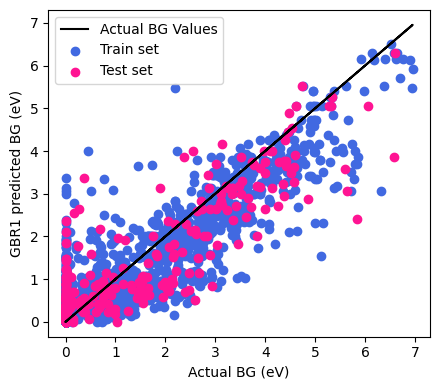

In [16]:

# GBR1 Plot

plt.figure(figsize=(4.5, 4))

# Perfect prediction line
plt.plot(y_train1, y_train1, color='black', label='Actual BG Values')

# Scatter plots
plt.scatter(
    y_train1,
    gbr_y_train_pred1,
    color='royalblue',
    #alpha=0.5,
    label=f'Train set'
)

plt.scatter(
    y_test1,
    gbr_y_pred1,
    color='deeppink',
    #alpha=0.5,
    label=f'Test set'
)

# Labels
plt.xlabel('Actual BG (eV)')
plt.ylabel('GBR1 predicted BG (eV)')

# Legend
plt.legend()

# Save figure
plt.savefig('GBR1_BG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

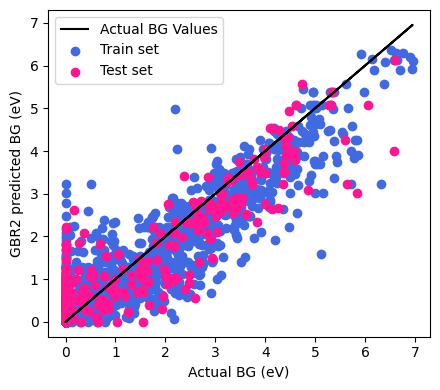

In [17]:
# GBR2 Plot
plt.figure(figsize=(4.5, 4))

# Perfect prediction line
plt.plot(y_train2, y_train2, color='black', label='Actual BG Values')

# Scatter plots
plt.scatter(
    y_train2,
    gbr_y_train_pred2,
    color='royalblue',
    #alpha=0.5,
    label=f'Train set'
)

plt.scatter(
    y_test2,
    gbr_y_pred2,
    color='deeppink',
    #alpha=0.5,
    label=f'Test set'
)

# Labels
plt.xlabel('Actual BG (eV)')
plt.ylabel('GBR2 predicted BG (eV)')

# Legend
plt.legend()

# Save figure
plt.savefig('GBR2_BG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

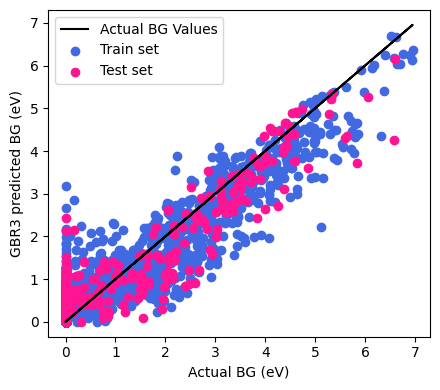

In [18]:
# GBR3 Plot

plt.figure(figsize=(4.5, 4))

# Perfect prediction line
plt.plot(y_train3, y_train3, color='black', label='Actual BG Values')

# Scatter plots
plt.scatter(
    y_train3,
    gbr_y_train_pred3,
    color='royalblue',
    #alpha=0.5,
    label=f'Train set'
)

plt.scatter(
    y_test3,
    gbr_y_pred3,
    color='deeppink',
    #alpha=0.5,
    label=f'Test set'
)

# Labels
plt.xlabel('Actual BG (eV)')
plt.ylabel('GBR3 predicted BG (eV)')

# Legend
plt.legend()

# Save figure
plt.savefig('GBR3_BG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

##CatBoost

In [19]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [20]:
from sklearn.model_selection import KFold, cross_val_score
from catboost import CatBoostRegressor

# Same 10 folds for all three models
kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

models = {
    "CatBoost Model 1": (X_train1, y_train1),
    "CatBoost Model 2": (X_train2, y_train2),
    "CatBoost Model 3": (X_train3, y_train3)
}

cv_results_cb = {}

for name, (X, y) in models.items():

    cb = CatBoostRegressor(
        random_state=42,
        verbose=0
    )

    mse_scores = cross_val_score(
        estimator=cb,
        X=X,
        y=y,
        cv=kf,
        scoring="neg_mean_squared_error"
    )

    rmse_scores = np.sqrt(-mse_scores)

    cv_results_cb[name] = {
        "fold_rmse": rmse_scores,
        "mean_rmse": rmse_scores.mean(),
        "std_rmse": rmse_scores.std()
    }

    print(f"\n{name}")
    print("Fold RMSE :", np.round(rmse_scores, 4))
    print(f"Mean RMSE : {rmse_scores.mean():.4f}")
    print(f"Std RMSE  : {rmse_scores.std():.4f}")


CatBoost Model 1
Fold RMSE : [0.87 0.8  0.92 0.85 0.82 0.83 0.87 0.98 0.87 0.85]
Mean RMSE : 0.8655
Std RMSE  : 0.0511

CatBoost Model 2
Fold RMSE : [0.71 0.71 0.76 0.77 0.73 0.67 0.74 0.85 0.75 0.76]
Mean RMSE : 0.7445
Std RMSE  : 0.0455

CatBoost Model 3
Fold RMSE : [0.6  0.69 0.65 0.61 0.62 0.58 0.64 0.79 0.61 0.66]
Mean RMSE : 0.6422
Std RMSE  : 0.0571


In [21]:
from catboost import CatBoostRegressor
# Define CatBoost Models

cb1 = CatBoostRegressor(random_state=42)
cb2 = CatBoostRegressor(random_state=42)
cb3 = CatBoostRegressor(random_state=42)

# Fit Models
cb1.fit(X_train1, y_train1, verbose=0)
cb2.fit(X_train2, y_train2, verbose=0)
cb3.fit(X_train3, y_train3, verbose=0)

CatBoostRegressor(loss_function='RMSE', random_state=42)

In [22]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error
)
# =========================
# CB1 Metrics
# =========================
cb_y_pred1 = cb1.predict(X_test1)
cb_y_pred1 = np.clip(cb_y_pred1, 0, None)

cb_y_pred1 = cb_y_pred1.reshape(len(cb_y_pred1), 1)

cb1_r2 = r2_score(y_test1, cb_y_pred1)
cb1_r = np.corrcoef(y_test1.squeeze(), cb_y_pred1.squeeze())[0, 1]
cb1_mae = mean_absolute_error(y_test1, cb_y_pred1)
cb1_medae = median_absolute_error(y_test1, cb_y_pred1)
cb1_mse = mean_squared_error(y_test1, cb_y_pred1)
cb1_rmse = np.sqrt(cb1_mse)

print("CB1 Results")
print("R2:", cb1_r2)
print("R value:", cb1_r)
print("MAE:", cb1_mae)
print("Median Absolute Error:", cb1_medae)
print("MSE:", cb1_mse)
print("RMSE:", cb1_rmse)


# =========================
# CB2 Metrics
# =========================
cb_y_pred2 = cb2.predict(X_test2)

# Replace negative predictions with 0
cb_y_pred2 = np.clip(cb_y_pred2, 0, None)

cb_y_pred2 = cb_y_pred2.reshape(len(cb_y_pred2), 1)

cb2_r2 = r2_score(y_test2, cb_y_pred2)
cb2_r = np.corrcoef(y_test2.squeeze(), cb_y_pred2.squeeze())[0, 1]
cb2_mae = mean_absolute_error(y_test2, cb_y_pred2)
cb2_medae = median_absolute_error(y_test2, cb_y_pred2)
cb2_mse = mean_squared_error(y_test2, cb_y_pred2)
cb2_rmse = np.sqrt(cb2_mse)

print("\nCB2 Results")
print("R2:", cb2_r2)
print("R value:", cb2_r)
print("MAE:", cb2_mae)
print("Median Absolute Error:", cb2_medae)
print("MSE:", cb2_mse)
print("RMSE:", cb2_rmse)


# =========================
# CB3 Metrics
# =========================
cb_y_pred3 = cb3.predict(X_test3)
cb_y_pred3 = np.clip(cb_y_pred3, 0, None)
cb_y_pred3 = cb_y_pred3.reshape(len(cb_y_pred3), 1)

cb3_r2 = r2_score(y_test3, cb_y_pred3)
cb3_r = np.corrcoef(y_test3.squeeze(), cb_y_pred3.squeeze())[0, 1]
cb3_mae = mean_absolute_error(y_test3, cb_y_pred3)
cb3_medae = median_absolute_error(y_test3, cb_y_pred3)
cb3_mse = mean_squared_error(y_test3, cb_y_pred3)
cb3_rmse = np.sqrt(cb3_mse)

print("\nCB3 Results")
print("R2:", cb3_r2)
print("R value:", cb3_r)
print("MAE:", cb3_mae)
print("Median Absolute Error:", cb3_medae)
print("MSE:", cb3_mse)
print("RMSE:", cb3_rmse)

CB1 Results
R2: 0.7887492635460496
R value: 0.8882262779078252
MAE: 0.47312722479072983
Median Absolute Error: 0.23974629807969228
MSE: 0.5638720090496091
RMSE: 0.7509141156281517

CB2 Results
R2: 0.8688714245242902
R value: 0.9326451991157829
MAE: 0.3809951819054007
Median Absolute Error: 0.22053863890637437
MSE: 0.35000935162855434
RMSE: 0.5916158818258299

CB3 Results
R2: 0.9112160301281828
R value: 0.9551124823877413
MAE: 0.31260062297677604
Median Absolute Error: 0.16972496162389827
MSE: 0.23698282099922777
RMSE: 0.4868088136006042


In [23]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error
)
import numpy as np

# =========================
# CB1 Train Metrics
# =========================
cb_y_train_pred1 = cb1.predict(X_train1)
cb_y_train_pred1 = np.clip(cb_y_train_pred1, 0, None)
cb_y_train_pred1 = cb_y_train_pred1.reshape(len(cb_y_train_pred1), 1)

cb1_train_r2 = r2_score(y_train1, cb_y_train_pred1)
cb1_train_r = np.corrcoef(y_train1.squeeze(), cb_y_train_pred1.squeeze())[0, 1]
cb1_train_mae = mean_absolute_error(y_train1, cb_y_train_pred1)
cb1_train_medae = median_absolute_error(y_train1, cb_y_train_pred1)
cb1_train_mse = mean_squared_error(y_train1, cb_y_train_pred1)
cb1_train_rmse = np.sqrt(cb1_train_mse)

print("CB1 Train Results")
print("R2:", cb1_train_r2)
print("R value:", cb1_train_r)
print("MAE:", cb1_train_mae)
print("Median Absolute Error:", cb1_train_medae)
print("MSE:", cb1_train_mse)
print("RMSE:", cb1_train_rmse)


# =========================
# CB2 Train Metrics
# =========================
cb_y_train_pred2 = cb2.predict(X_train2)
cb_y_train_pred2 = np.clip(cb_y_train_pred2, 0, None)
cb_y_train_pred2 = cb_y_train_pred2.reshape(len(cb_y_train_pred2), 1)

cb2_train_r2 = r2_score(y_train2, cb_y_train_pred2)
cb2_train_r = np.corrcoef(y_train2.squeeze(), cb_y_train_pred2.squeeze())[0, 1]
cb2_train_mae = mean_absolute_error(y_train2, cb_y_train_pred2)
cb2_train_medae = median_absolute_error(y_train2, cb_y_train_pred2)
cb2_train_mse = mean_squared_error(y_train2, cb_y_train_pred2)
cb2_train_rmse = np.sqrt(cb2_train_mse)

print("\nCB2 Train Results")
print("R2:", cb2_train_r2)
print("R value:", cb2_train_r)
print("MAE:", cb2_train_mae)
print("Median Absolute Error:", cb2_train_medae)
print("MSE:", cb2_train_mse)
print("RMSE:", cb2_train_rmse)


# =========================
# CB3 Train Metrics
# =========================
cb_y_train_pred3 = cb3.predict(X_train3)
cb_y_train_pred3 = np.clip(cb_y_train_pred3, 0, None)
cb_y_train_pred3 = cb_y_train_pred3.reshape(len(cb_y_train_pred3), 1)

cb3_train_r2 = r2_score(y_train3, cb_y_train_pred3)
cb3_train_r = np.corrcoef(y_train3.squeeze(), cb_y_train_pred3.squeeze())[0, 1]
cb3_train_mae = mean_absolute_error(y_train3, cb_y_train_pred3)
cb3_train_medae = median_absolute_error(y_train3, cb_y_train_pred3)
cb3_train_mse = mean_squared_error(y_train3, cb_y_train_pred3)
cb3_train_rmse = np.sqrt(cb3_train_mse)

print("\nCB3 Train Results")
print("R2:", cb3_train_r2)
print("R value:", cb3_train_r)
print("MAE:", cb3_train_mae)
print("Median Absolute Error:", cb3_train_medae)
print("MSE:", cb3_train_mse)
print("RMSE:", cb3_train_rmse)

CB1 Train Results
R2: 0.8818198731081718
R value: 0.9396401284398991
MAE: 0.3245704462617419
Median Absolute Error: 0.16894363331049278
MSE: 0.2942816136088093
RMSE: 0.5424772931734648

CB2 Train Results
R2: 0.944677121149
R value: 0.972953155167374
MAE: 0.2303236736275716
Median Absolute Error: 0.14828311652718928
MSE: 0.13776009965413807
RMSE: 0.3711604769559093

CB3 Train Results
R2: 0.9785853107286613
R value: 0.9899893208975741
MAE: 0.1549994856841028
Median Absolute Error: 0.10018972884842875
MSE: 0.053324949629382966
RMSE: 0.23092195571097818


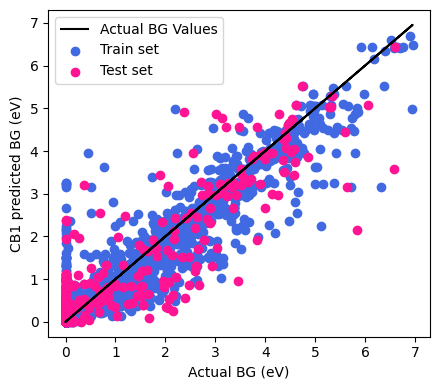

In [24]:
# =========================
# CB1 Plot
# =========================

plt.figure(figsize=(4.5, 4))

# Perfect prediction line
plt.plot(y_train1, y_train1, color='black', label='Actual BG Values')

# Scatter plots
plt.scatter(
    y_train1,
    cb_y_train_pred1,
    color='royalblue',
    #alpha=0.5,
    label=f'Train set'
)

plt.scatter(
    y_test1,
    cb_y_pred1,
    color='deeppink',
    #alpha=0.5,
    label=f'Test set'
)

# Labels
plt.xlabel('Actual BG (eV)')
plt.ylabel('CB1 predicted BG (eV)')

# Legend
plt.legend()

# Save figure
plt.savefig('CB1_BG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

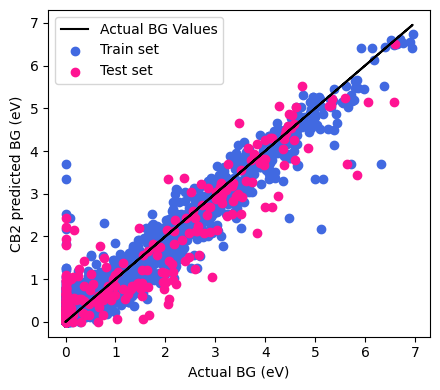

In [25]:
# =========================
# CB2 Plot
# =========================

plt.figure(figsize=(4.5, 4))

# Perfect prediction line
plt.plot(y_train2, y_train2, color='black', label='Actual BG Values')

# Scatter plots
plt.scatter(
    y_train2,
    cb_y_train_pred2,
    color='royalblue',
    #alpha=0.5,
    label=f'Train set'
)

plt.scatter(
    y_test2,
    cb_y_pred2,
    color='deeppink',
    #alpha=0.5,
    label=f'Test set'
)

# Labels
plt.xlabel('Actual BG (eV)')
plt.ylabel('CB2 predicted BG (eV)')

# Legend
plt.legend()

# Save figure
plt.savefig('CB2_BG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

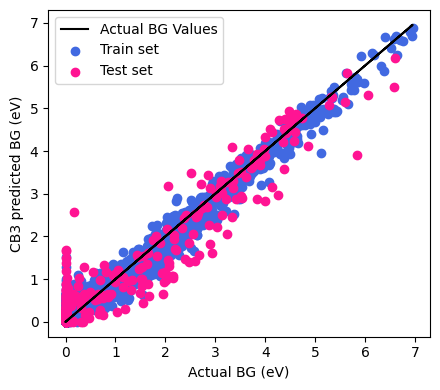

In [26]:
# =========================
# CB3 Plot
# =========================

plt.figure(figsize=(4.5, 4))

# Perfect prediction line
plt.plot(y_train3, y_train3, color='black', label='Actual BG Values')

# Scatter plots
plt.scatter(
    y_train3,
    cb_y_train_pred3,
    color='royalblue',
    #alpha=0.5,
    label=f'Train set'
)

plt.scatter(
    y_test3,
    cb_y_pred3,
    color='deeppink',
    #alpha=0.5,
    label=f'Test set'
)

# Labels
plt.xlabel('Actual BG (eV)')
plt.ylabel('CB3 predicted BG (eV)')

# Legend
plt.legend()

# Save figure
plt.savefig('CB3_BG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

#RMSE & R2 plot

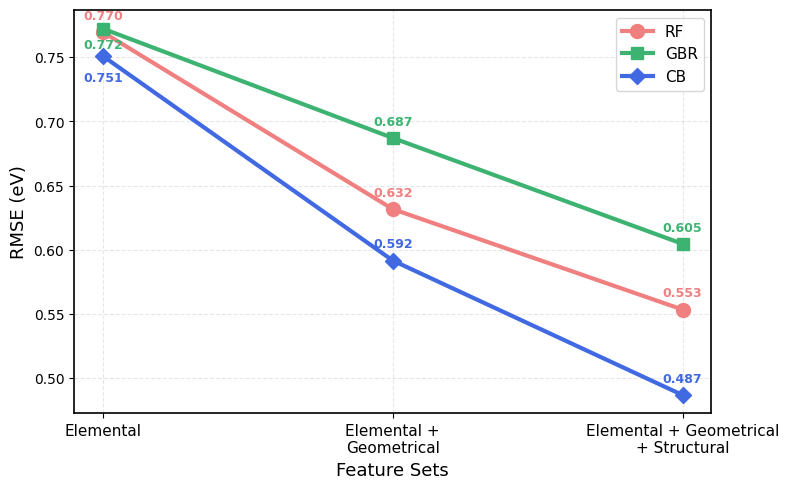

In [28]:
# ==========================================
# Improved RMSE Ablation Plot
# ==========================================
feature_sets = [
    'Elemental',
    'Elemental +\nGeometrical',
    'Elemental + Geometrical\n+ Structural'
]

x = np.arange(len(feature_sets))

rf_rmse = [rf1_rmse, rf2_rmse, rf3_rmse]
gbr_rmse = [gbr1_rmse, gbr2_rmse, gbr3_rmse]
cb_rmse = [cb1_rmse, cb2_rmse, cb3_rmse]

plt.figure(figsize=(8,5))

# ==========================================
# Lines
# RF and CB colors exchanged
# ==========================================
plt.plot(x, rf_rmse,
         marker='o', markersize=10,
         linewidth=3,
         color='lightcoral',
         label='RF')

plt.plot(x, gbr_rmse,
         marker='s', markersize=9,
         linewidth=3,
         color='mediumseagreen',
         label='GBR')

plt.plot(x, cb_rmse,
         marker='D', markersize=8,
         linewidth=3,
         color='royalblue',
         label='CB')

# ==========================================
# RF Labels
# ==========================================
for i, value in enumerate(rf_rmse):

    plt.text(
        x[i],
        value + 0.01,
        f'{value:.3f}',
        ha='center',
        color='lightcoral',
        fontsize=9,
        fontweight='bold'
    )

# ==========================================
# GBR Labels
# Move first value downward
# ==========================================
for i, value in enumerate(gbr_rmse):

    if i == 0:
        y_pos = value - 0.015
    else:
        y_pos = value + 0.01

    plt.text(
        x[i],
        y_pos,
        f'{value:.3f}',
        ha='center',
        color='mediumseagreen',
        fontsize=9,
        fontweight='bold'
    )

# ==========================================
# CB Labels
# Move first value downward
# ==========================================

for i, value in enumerate(cb_rmse):

    if i == 0:
        y_pos = value - 0.02
    else:
        y_pos = value + 0.01

    plt.text(
        x[i],
        y_pos,
        f'{value:.3f}',
        ha='center',
        color='royalblue',
        fontsize=9,
        fontweight='bold'
    )

# ==========================================
# Axis Labels
# ==========================================
plt.xticks(
    x,
    feature_sets,
    fontsize=11
)

plt.ylabel(
    'RMSE (eV)',
    fontsize=13
)

plt.xlabel(
    'Feature Sets',
    fontsize=13
)

# ==========================================
# Grid
# ==========================================

plt.grid(
    linestyle='--',
    alpha=0.3
)

# ==========================================
# Legend
# ==========================================
plt.legend(
    fontsize=11,
    frameon=True
)

# ==========================================
# Frame Thickness
# ==========================================
ax = plt.gca()

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# ==========================================
# Save Figure
# ==========================================
plt.tight_layout()
plt.savefig(
    'RMSE_Ablation_Study.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

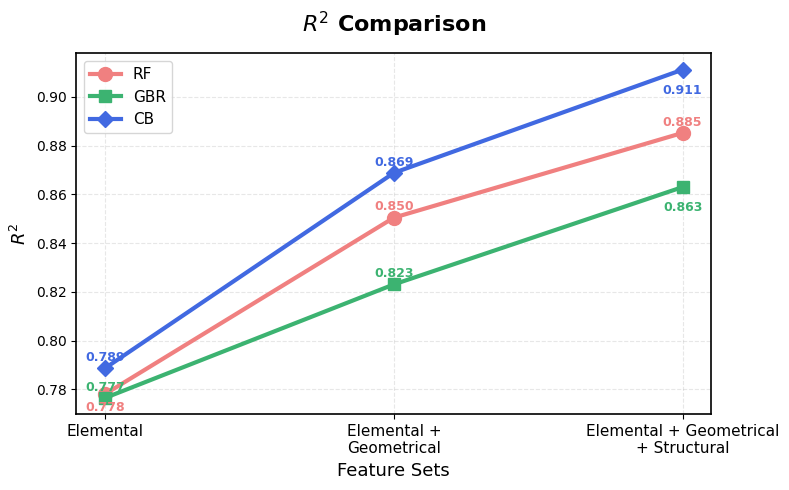

In [29]:
# ==========================================
# Improved R2 Ablation Plot
# ==========================================
feature_sets = [
    'Elemental',
    'Elemental +\nGeometrical',
    'Elemental + Geometrical\n+ Structural'
]

x = np.arange(len(feature_sets))

# ==========================================
# R2 Values
# ==========================================
rf_r2 = [rf1_r2, rf2_r2, rf3_r2]
gbr_r2 = [gbr1_r2, gbr2_r2, gbr3_r2]
cb_r2 = [cb1_r2, cb2_r2, cb3_r2]

# ==========================================
# Figure
# ==========================================
plt.figure(figsize=(8,5))

# ==========================================
# Lines
# RF and CB colors exchanged
# ==========================================
plt.plot(
    x,
    rf_r2,
    marker='o',
    markersize=10,
    linewidth=3,
    color='lightcoral',
    label='RF'
)

plt.plot(
    x,
    gbr_r2,
    marker='s',
    markersize=9,
    linewidth=3,
    color='mediumseagreen',
    label='GBR'
)

plt.plot(
    x,
    cb_r2,
    marker='D',
    markersize=8,
    linewidth=3,
    color='royalblue',
    label='CB'
)

# ==========================================
# RF Labels
# Move first RF value downward
# ==========================================
for i, value in enumerate(rf_r2):

    if i == 0:
        y_pos = value - 0.007
    else:
        y_pos = value + 0.003

    plt.text(
        x[i],
        y_pos,
        f'{value:.3f}',
        ha='center',
        color='lightcoral',
        fontsize=9,
        fontweight='bold'
    )

# ==========================================
# GBR Labels
# Move last GBR value downward
# ==========================================
for i, value in enumerate(gbr_r2):

    if i == 2:
        y_pos = value - 0.01
    else:
        y_pos = value + 0.003

    plt.text(
        x[i],
        y_pos,
        f'{value:.3f}',
        ha='center',
        color='mediumseagreen',
        fontsize=9,
        fontweight='bold'
    )

# ==========================================
# CB Labels
# Move last CB value downward
# ==========================================
for i, value in enumerate(cb_r2):

    if i == 2:
        y_pos = value - 0.01
    else:
        y_pos = value + 0.003

    plt.text(
        x[i],
        y_pos,
        f'{value:.3f}',
        ha='center',
        color='royalblue',
        fontsize=9,
        fontweight='bold'
    )

# ==========================================
# Axis Labels
# ==========================================
plt.xticks(
    x,
    feature_sets,
    fontsize=11
)

plt.ylabel(
    r'$R^2$',
    fontsize=13
)

plt.xlabel(
    'Feature Sets',
    fontsize=13
)

# ==========================================
# Grid
# ==========================================
plt.grid(
    linestyle='--',
    alpha=0.3
)

# ==========================================
# Legend
# ==========================================
plt.legend(
    fontsize=11,
    frameon=True
)

# ==========================================
# Title
# ==========================================
plt.title(
    r'$R^2$ Comparison',
    fontsize=16,
    fontweight='bold',
    pad=15
)

# ==========================================
# Frame Thickness
# ==========================================

ax = plt.gca()

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# ==========================================
# Save Figure
# ==========================================
plt.tight_layout()

plt.savefig(
    'R2_Ablation_Study.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#Hyperparameter tuning using Optuna

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 20.1 MB/s eta 0:00:00


In [ ]:
import optuna
def objective4(trial):
    # Define the hyperparameters to be optimized
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-5, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        'border_count': trial.suggest_int('border_count', 1, 255),
        'od_type': trial.suggest_categorical('od_type', ['IncToDec', 'Iter']),
        'od_wait': trial.suggest_int('od_wait', 10, 50)
    }

    # Create the CatBoost model
    model = CatBoostRegressor(
        **params,
        logging_level='Silent',
        random_seed=42
    )

    # Perform cross-validation
    score = cross_val_score(model, X_train3, y_train3, cv=10, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-score.mean())

    return rmse
# Create the Optuna study and optimize the objective function
study4 = optuna.create_study(direction='minimize')
study4.optimize(objective4, n_trials=50)

[I 2026-09-02 06:22:20,967] A new study created in memory with name: no-name-8ee4762f-2286-4c07-9866-122561ba3c62
[I 2026-09-02 06:24:12,807] Trial 0 finished with value: 1.2053713163683517 and parameters: {'iterations': 362, 'depth': 10, 'learning_rate': 0.0020803690331276602, 'l2_leaf_reg': 4.0863874167790236e-05, 'bagging_temperature': 0.6547245639099122, 'random_strength': 6.366993603745472, 'border_count': 13, 'od_type': 'Iter', 'od_wait': 20}. Best is trial 0 with value: 1.2053713163683517.
[I 2026-09-02 06:25:24,987] Trial 1 finished with value: 0.6611817151293147 and parameters: {'iterations': 365, 'depth': 6, 'learning_rate': 0.02749467830836535, 'l2_leaf_reg': 0.36957886123417616, 'bagging_temperature': 0.8166475369154258, 'random_strength': 1.2944059148939781e-05, 'border_count': 223, 'od_type': 'IncToDec', 'od_wait': 49}. Best is trial 1 with value: 0.6611817151293147.
[I 2026-09-02 06:29:20,863] Trial 2 finished with value: 0.6686316188369203 and parameters: {'iterations':

In [ ]:
# Print the best hyperparameters and the best score
print(f'Best trial: {study4.best_trial.number}')
print("Best hyperparameters: ", study4.best_params)
#{'iterations': 984, 'depth': 9, 'learning_rate': 0.02423057754481626, 'l2_leaf_reg': 4.411899015361824, 'bagging_temperature': 0.3302865260909996, 'random_strength': 3.758643425296768e-09, 'border_count': 63, 'od_type': 'IncToDec', 'od_wait': 48}
print("Best RMSE: ", study4.best_value)

Best trial: 39
Best hyperparameters:  {'iterations': 984, 'depth': 9, 'learning_rate': 0.02423057754481626, 'l2_leaf_reg': 4.411899015361824, 'bagging_temperature': 0.3302865260909996, 'random_strength': 3.758643425296768e-09, 'border_count': 63, 'od_type': 'IncToDec', 'od_wait': 48}
Best RMSE:  0.6141324460148122


#CB3_Optimized Algorithm


In [30]:
from sklearn.model_selection import KFold, cross_val_score
from catboost import CatBoostRegressor

# Train the model with the best hyperparameters
best_cb = CatBoostRegressor(
    iterations=984,
    depth=9,
    learning_rate=0.02423057754481626,
    l2_leaf_reg=4.411899015361824,
    bagging_temperature=0.3302865260909996,
    random_strength=3.758643425296768e-09,
    border_count=63,
    od_type='IncToDec',
    od_wait=48,
    random_seed=42
)
best_cb.fit(X_train3, y_train3, verbose=0)

mse_scores = cross_val_score(estimator = best_cb, X = X_train3, y = y_train3, cv = 10, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-mse_scores)
print("RMSE: {:.4f}".format(rmse_scores.mean()))
print("Standard Deviation: {:.4f}".format(rmse_scores.std()))

Streaming output truncated to the last 5000 lines.
906:	learn: 0.1976738	total: 33.5s	remaining: 2.84s
907:	learn: 0.1974103	total: 33.5s	remaining: 2.8s
908:	learn: 0.1970449	total: 33.5s	remaining: 2.77s
909:	learn: 0.1969418	total: 33.6s	remaining: 2.73s
910:	learn: 0.1966299	total: 33.6s	remaining: 2.69s
911:	learn: 0.1964773	total: 33.6s	remaining: 2.65s
912:	learn: 0.1960974	total: 33.7s	remaining: 2.62s
913:	learn: 0.1958154	total: 33.7s	remaining: 2.58s
914:	learn: 0.1955631	total: 33.7s	remaining: 2.54s
915:	learn: 0.1953566	total: 33.8s	remaining: 2.51s
916:	learn: 0.1952412	total: 33.8s	remaining: 2.47s
917:	learn: 0.1948811	total: 33.8s	remaining: 2.43s
918:	learn: 0.1945678	total: 33.9s	remaining: 2.4s
919:	learn: 0.1944252	total: 33.9s	remaining: 2.36s
920:	learn: 0.1943118	total: 33.9s	remaining: 2.32s
921:	learn: 0.1940720	total: 34s	remaining: 2.28s
922:	learn: 0.1939619	total: 34s	remaining: 2.25s
923:	learn: 0.1936337	total: 34s	remaining: 2.21s
924:	learn: 0.1933668

In [31]:
from sklearn.metrics import median_absolute_error

y_pred_n3 = best_cb.predict(X_test3)
y_pred_n3 = np.clip(y_pred_n3, 0, None)
y_pred_n3 = y_pred_n3.reshape(len(y_pred_n3), 1)
r_value3 = np.corrcoef(y_test3.squeeze(), y_pred_n3.squeeze())[0, 1]

# Calculate metrics on the test set
print("R2 on Test Set:", r2_score(y_test3, y_pred_n3))
print("R value:", r_value3)
print("MAE on Test Set:", mean_absolute_error(y_test3, y_pred_n3))
print("Median Absolute Error on Test Set:", median_absolute_error(y_test3, y_pred_n3))
print("MSE on Test Set:", mean_squared_error(y_test3, y_pred_n3))
print("RMSE on Test Set:", np.sqrt(mean_squared_error(y_test3, y_pred_n3)))

R2 on Test Set: 0.9169389254381995
R value: 0.9587155452131417
MAE on Test Set: 0.29718778063497003
Median Absolute Error on Test Set: 0.15509102171336242
MSE on Test Set: 0.22170722702872733
RMSE on Test Set: 0.4708579690615073


In [32]:
# CB on Train set
y_train_pred_n3 = best_cb.predict(X_train3)
y_train_pred_n3 = np.clip(y_train_pred_n3, 0, None)
y_train_pred_n3 = y_train_pred_n3.reshape(len(y_train_pred_n3), 1)
r_value_p3 = np.corrcoef(y_train3.squeeze(), y_train_pred_n3.squeeze())[0, 1]

# Calculate metrics on the train set
print("R2 on Train Set:", r2_score(y_train3, y_train_pred_n3))
print("R value:", r_value_p3)
print("MAE on Train Set:", mean_absolute_error(y_train3, y_train_pred_n3))
print("Median Absolute Error on Train Set:", median_absolute_error(y_train3, y_train_pred_n3))
print("MSE on Train Set:", mean_squared_error(y_train3, y_train_pred_n3))
print("RMSE on Train Set:", np.sqrt(mean_squared_error(y_train3, y_train_pred_n3)))

R2 on Train Set: 0.9856656551900848
R value: 0.9933175504925643
MAE on Train Set: 0.12348273233400342
Median Absolute Error on Train Set: 0.07677285628895336
MSE on Train Set: 0.03569410722115763
RMSE on Train Set: 0.18892884168691035


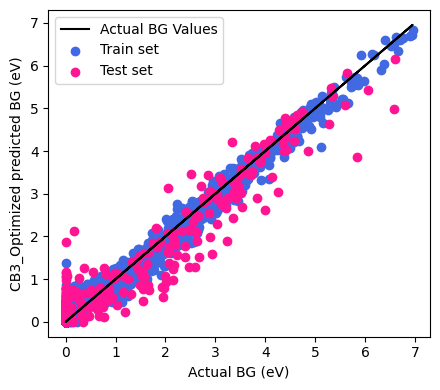

In [33]:
# =========================
# CB3 Plot
# =========================

plt.figure(figsize=(4.5, 4))

# Perfect prediction line
plt.plot(y_train3, y_train3, color='black', label='Actual BG Values')

# Scatter plots
plt.scatter(
    y_train3,
    y_train_pred_n3,
    color='royalblue',
    #alpha=0.5,
    label=f'Train set'
)

plt.scatter(
    y_test3,
    y_pred_n3,
    color='deeppink',
    #alpha=0.5,
    label=f'Test set'
)

# Labels
plt.xlabel('Actual BG (eV)')
plt.ylabel('CB3_Optimized predicted BG (eV)')

# Legend
plt.legend()

# Save figure
plt.savefig('Optimized_CB3_BG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

#Feature Importance Analysis

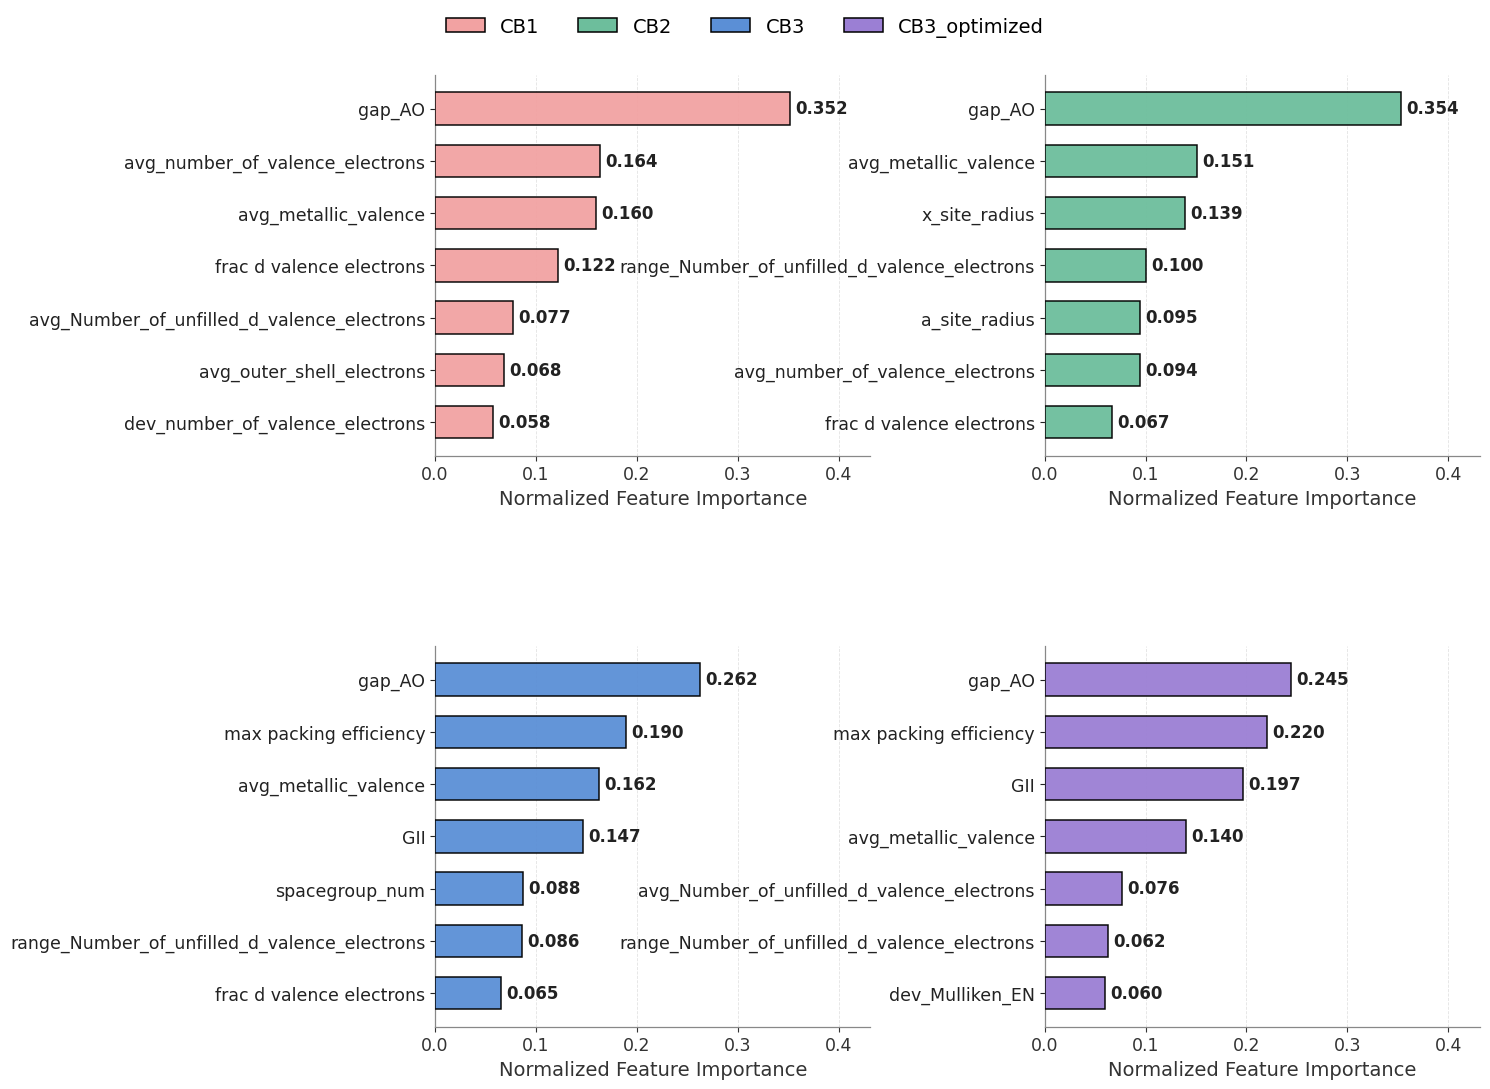

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==========================================
# Global Style
# ==========================================

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

color1 = '#F2A2A2'      # CB1
color2 = '#6DBE9C'      # CB2
color3 = '#5B8FD6'      # CB3
color_best = '#9B7FD4'  # CB3_optimised

# ==========================================
# Top 7 Features from Each CB Model
#
# IMPORTANT: feature names now come from cols_set1/cols_set2/
# cols_set3 (built in Script 2 from column_groups.json), NOT
# from dfx1/dfx2/dfx3.columns. The old dfx1/dfx2/dfx3 dataframes
# belonged to the pre-correlation-filtering pipeline and no
# longer match the actual number/order of features the retrained
# models were fit on -- using them here would silently mislabel
# every bar in this plot.
#
# best_cb is the hyperparameter-optimised CB3 model, so it is
# paired with cols_set3 (same feature set as cb3).
# ==========================================

cb1_imp = pd.DataFrame({
    'Feature': cols_set1,
    'Importance': cb1.feature_importances_
}).sort_values(by='Importance', ascending=False).head(7)

cb2_imp = pd.DataFrame({
    'Feature': cols_set2,
    'Importance': cb2.feature_importances_
}).sort_values(by='Importance', ascending=False).head(7)

cb3_imp = pd.DataFrame({
    'Feature': cols_set3,
    'Importance': cb3.feature_importances_
}).sort_values(by='Importance', ascending=False).head(7)

best_cb_imp = pd.DataFrame({
    'Feature': cols_set3,
    'Importance': best_cb.feature_importances_
}).sort_values(by='Importance', ascending=False).head(7)

# ------------------------------------------------------------
# Sanity check: catches a length mismatch immediately instead
# of a silent/confusing pandas error mid-plot
# ------------------------------------------------------------
for label, feat_list, model in [
    ("cb1", cols_set1, cb1),
    ("cb2", cols_set2, cb2),
    ("cb3", cols_set3, cb3),
    ("best_cb", cols_set3, best_cb),
]:
    n_feat = len(feat_list)
    n_imp = len(model.feature_importances_)
    if n_feat != n_imp:
        raise ValueError(
            f"{label}: feature list length ({n_feat}) does not match "
            f"feature_importances_ length ({n_imp}). The model was "
            f"likely fit on a different column set than the one "
            f"passed here -- double check which cols_setN was used "
            f"to fit this specific model."
        )

for df in [cb1_imp, cb2_imp, cb3_imp, best_cb_imp]:
    df['Importance'] = df['Importance'] / df['Importance'].sum()

x_max = max(df['Importance'].max() for df in [cb1_imp, cb2_imp, cb3_imp, best_cb_imp])
x_lim = x_max * 1.22

# ==========================================
# Create 2 x 2 Figure
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

plot_data = [
    (cb1_imp, color1),
    (cb2_imp, color2),
    (cb3_imp, color3),
    (best_cb_imp, color_best),
]

for ax, (imp_df, color) in zip(axes, plot_data):

    features = imp_df['Feature'].iloc[::-1]
    importance = imp_df['Importance'].iloc[::-1]

    bars = ax.barh(
        features,
        importance,
        color=color,
        edgecolor='black',
        linewidth=1.1,
        alpha=0.95,
        height=0.62,
        zorder=3,
    )

    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + x_lim * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f'{width:.3f}',
            va='center',
            ha='left',
            fontsize=12,
            fontweight='bold',
            color='#222222',
        )

    ax.set_xlim(0, x_lim)
    ax.set_xlabel('Normalized Feature Importance', fontsize=14, color='#333333')
    ax.tick_params(axis='x', labelsize=12.5, colors='#333333')
    ax.tick_params(axis='y', labelsize=12.5, colors='#222222')

    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_color('#888888')
        ax.spines[side].set_linewidth(0.9)

# ==========================================
# Shared Legend (CB1 / CB2 / CB3 / CB3_optimised)
# ==========================================

legend_handles = [
    Patch(facecolor=color1, edgecolor='black', linewidth=1.1, label='CB1'),
    Patch(facecolor=color2, edgecolor='black', linewidth=1.1, label='CB2'),
    Patch(facecolor=color3, edgecolor='black', linewidth=1.1, label='CB3'),
    Patch(facecolor=color_best, edgecolor='black', linewidth=1.1, label='CB3_optimized'),
]

fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.995),
    ncol=4,
    frameon=False,
    fontsize=14,
)

# ==========================================
# Layout
# ==========================================

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.subplots_adjust(hspace=0.5, wspace=0.4)

# ==========================================
# Save
# ==========================================

plt.savefig('CB_2x2_feature_importance.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

#SHAP Analysis

In [35]:
pip install shap

In [36]:
import shap
shap.initjs()

In [37]:
col = cols_set3
dfx_test = pd.DataFrame(data=X_test3, columns=col)
explainer = shap.Explainer(best_cb)
shap_values = explainer(dfx_test[0:])

In [38]:
explainer=shap.Explainer(best_cb)
shap_values=explainer(dfx_test[0:])

In [ ]:
np.shape(shap_values.values)

(352, 150)

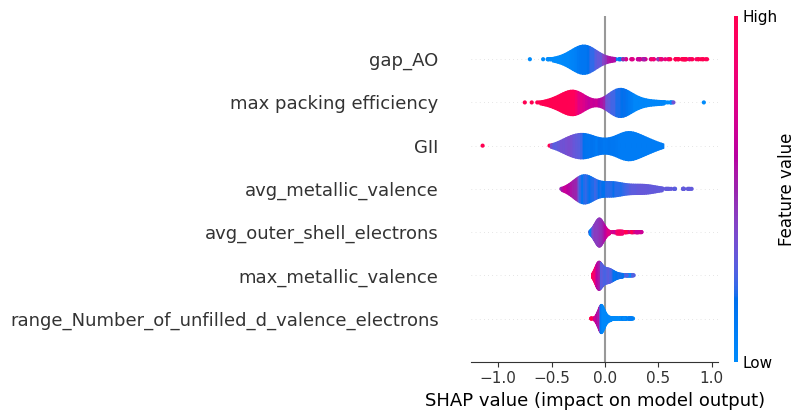

<Figure size 640x480 with 0 Axes>

In [39]:
plt.figure(figsize=(10, 4))
shap.summary_plot(
    shap_values,
    plot_type="violin",   # beeswarm style
    max_display=7
)

plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

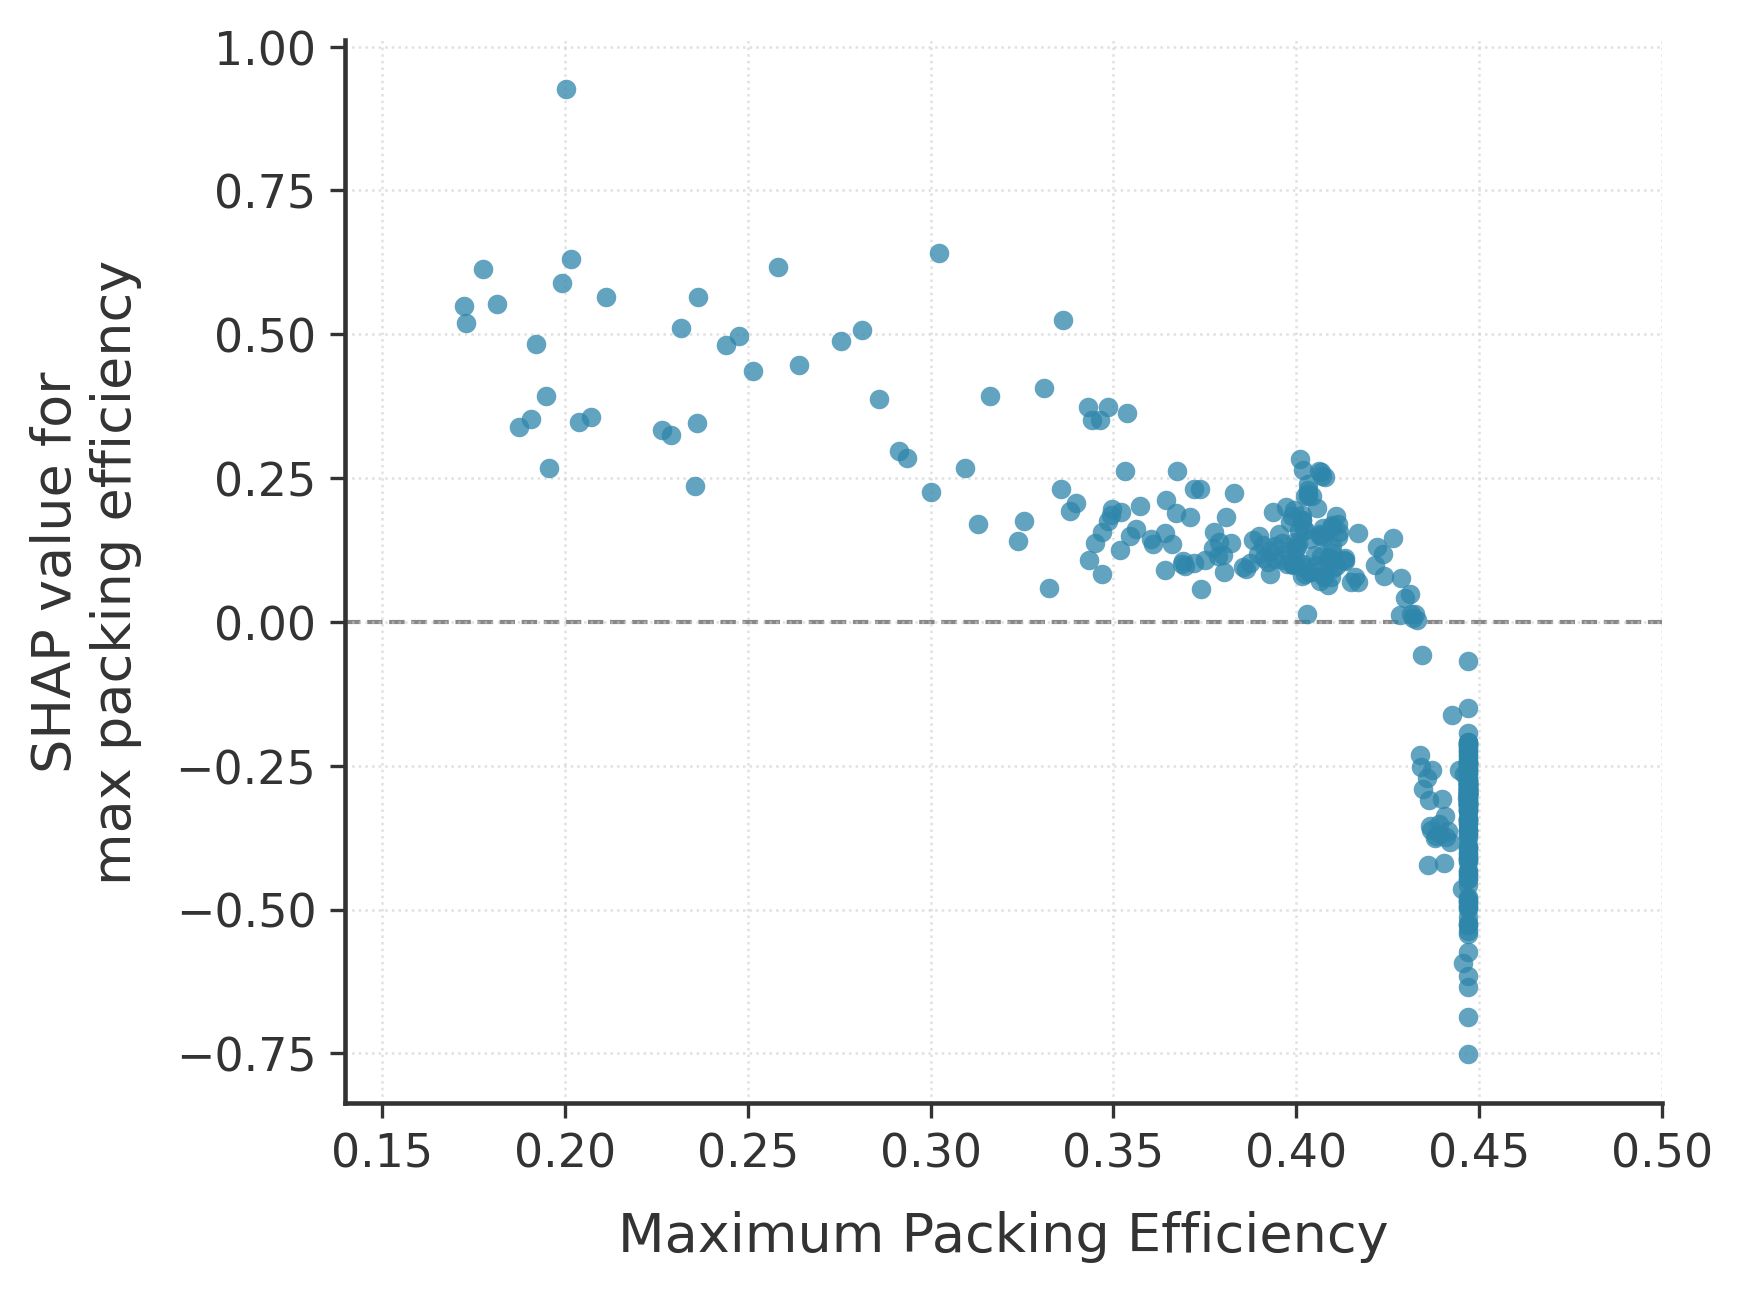

In [40]:
import matplotlib.pyplot as plt
import shap

# --- Style setup (journal-friendly, clean look) ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.labelweight": "normal",
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.1,
})

fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

shap.plots.scatter(
    shap_values[:, "max packing efficiency"],
    show=False,
    hist=False,
    ax=ax,
    dot_size=22,          # slightly larger, more legible points
    alpha=0.75,           # soft transparency to reveal density/overlap
    color="#2E86AB",      # single, deliberate accent color (swap for a colormap if coloring by a 3rd feature)
)

# --- Reference line at SHAP = 0 ---
ax.axhline(0, color="#888888", linestyle="--", linewidth=1, zorder=0)

# --- Axis labels & title ---
ax.set_xlabel("Maximum Packing Efficiency", labelpad=8)
ax.set_ylabel("SHAP value for\nmax packing efficiency", labelpad=8)
# --- Clean spines (remove top/right, keep left/bottom crisp) ---
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333333")
ax.spines["bottom"].set_color("#333333")

# --- Light grid for readability without clutter ---
ax.grid(True, linestyle=":", linewidth=0.6, color="#cccccc", alpha=0.6)
ax.set_axisbelow(True)

# --- Optional axis limits ---
ax.set_xlim(0.14, 0.5)
# ax.set_ylim(-0.7, 1.0)

plt.tight_layout()

# --- Save BEFORE show() to avoid a blank/empty saved figure ---
plt.savefig("mpa_shap.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

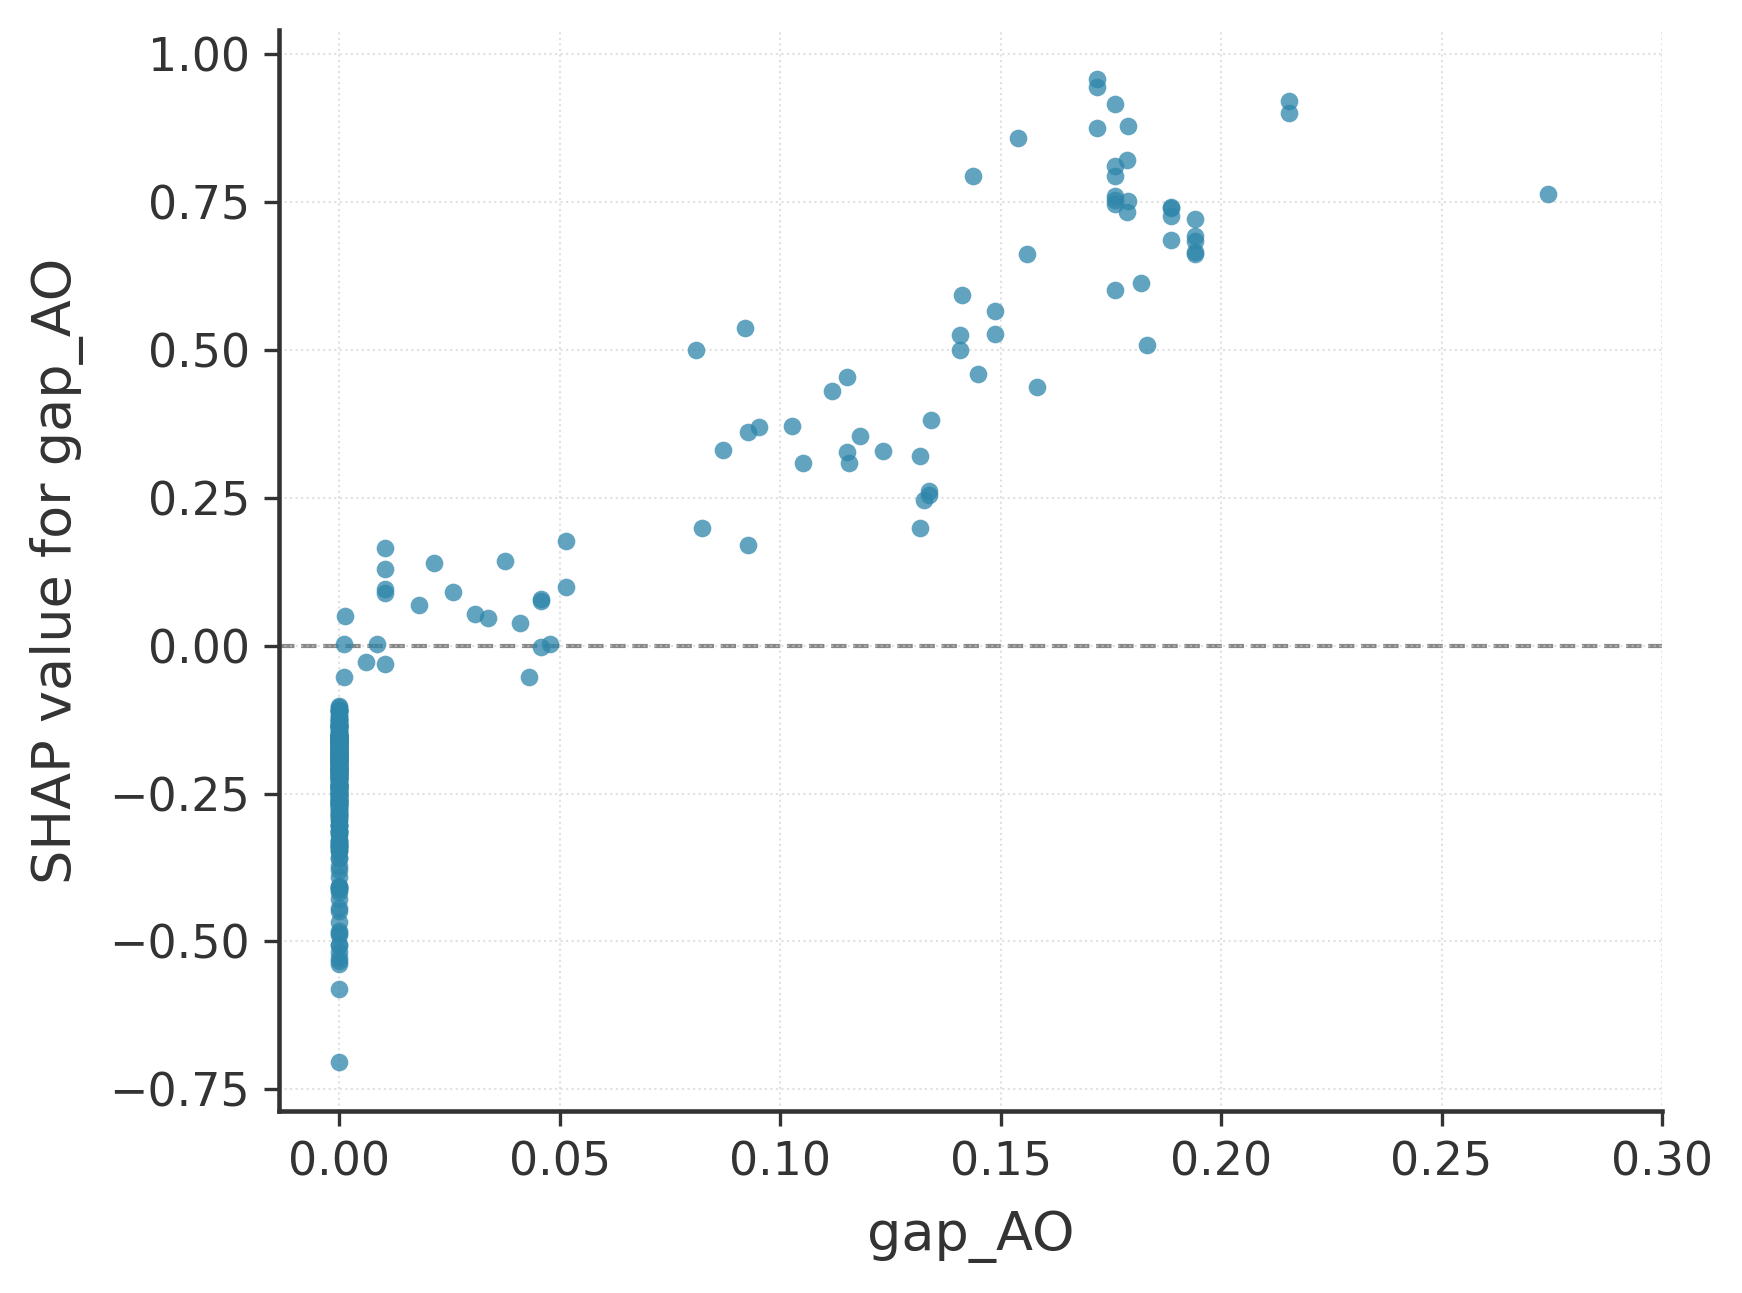

In [41]:
# --- Style setup (same as Maximum Packing Efficiency plot) ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.labelweight": "normal",
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.1,
})


fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

shap.plots.scatter(
    shap_values[:, "gap_AO"],
    show=False,
    hist=False,
    ax=ax,
    dot_size=18,
    alpha=0.75,
    color="#2E86AB",
)

# --- Reference line at SHAP = 0 ---
ax.axhline(
    0,
    color="#888888",
    linestyle="--",
    linewidth=1,
    zorder=0
)

# --- Axis labels ---
ax.set_xlabel("gap_AO", labelpad=6)
ax.set_ylabel("SHAP value for gap_AO", labelpad=6)

# --- X-axis ticks at 0.05 intervals, excluding -0.05 ---
xmin, xmax = ax.get_xlim()

ticks = np.arange(
    np.floor(xmin / 0.05) * 0.05,
    np.ceil(xmax / 0.05) * 0.05 + 0.05,
    0.05
)

ticks = ticks[ticks != -0.05]

ax.set_xticks(ticks)

# --- Clean spines ---
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333333")
ax.spines["bottom"].set_color("#333333")

# --- Light grid ---
ax.grid(
    True,
    linestyle=":",
    linewidth=0.5,
    color="#cccccc",
    alpha=0.6
)
ax.set_axisbelow(True)

plt.tight_layout()

# --- Save ---
plt.savefig(
    "gap_AO_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()